<a href="https://colab.research.google.com/github/Suhasri28/SDC-Activities/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

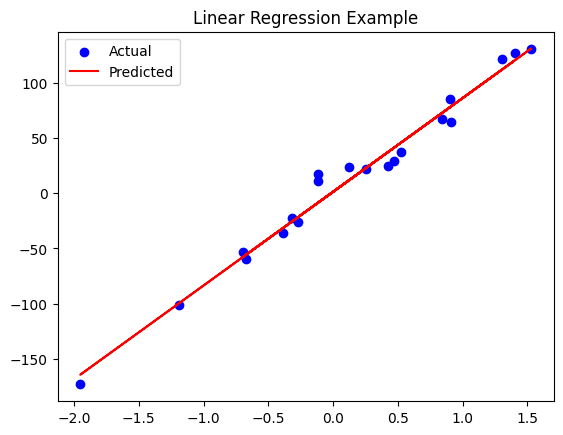

In [1]:
# 1_Linear_Regression/linear_regression.py

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# Generate synthetic data
X, y = make_regression(n_samples=100, n_features=1, noise=10)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Plot
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title('Linear Regression Example')
plt.legend()
plt.show()


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load the iris dataset
data = load_iris()
X = data.data
y = data.target

# For binary classification, we'll select only two classes (class 0 and class 1)
X = X[y != 2]
y = y[y != 2]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 100.00%


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load the iris dataset
data = load_iris()
X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 100.00%


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Create the ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(28, 28, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for the digits 0-9
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32, 10), output.shape=(32, 28, 28, 10)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Create the CNN model
model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D outputs for the fully connected layers
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),

    # Output layer
    Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - accuracy: 0.8778 - loss: 0.4133 - val_accuracy: 0.9796 - val_loss: 0.0693
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.9830 - loss: 0.0535 - val_accuracy: 0.9859 - val_loss: 0.0464
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9895 - loss: 0.0337

KeyboardInterrupt: 

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import numpy as np

# Generate a simple sequential dataset
X = np.array([[0], [1], [2], [3], [4], [5], [6], [7], [8], [9]])  # Input sequence
y = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Output sequence (target)

# Reshape X to be in the shape (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Build the RNN model
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(1, 1)),  # RNN layer with 50 units
    Dense(1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=200, verbose=0)

# Predict the next value in the sequence
prediction = model.predict(np.array([[[9]]]))  # Predicting the next value after 9
print("Predicted next value:", prediction)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Predicted next value: [[8.142275]]


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# Generate a simple sequential dataset (time series)
X = np.array([[0], [1], [2], [3], [4], [5], [6], [7], [8], [9]])  # Input sequence
y = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Output sequence (target)

# Reshape X to be in the shape (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(1, 1)),  # LSTM layer with 50 units
    Dense(1)  # Output layer to predict the next value
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=200, verbose=0)

# Predict the next value in the sequence
prediction = model.predict(np.array([[[9]]]))  # Predicting the next value after 9
print("Predicted next value:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Predicted next value: [[9.646165]]


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Simplified Capsule Network - Without Dynamic Routing
class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsules, dim_capsule, routings=3):
        super(CapsuleLayer, self).__init__()
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        # The number of capsules in the current layer is input_shape[1]
        self.W = self.add_weight(
            shape=(input_shape[1], self.num_capsules, self.dim_capsule, input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True,
        )

    def call(self, inputs):
        # Get the shape of the input
        batch_size = tf.shape(inputs)[0]
        inputs = tf.expand_dims(inputs, 2)
        inputs = tf.tile(inputs, [1, 1, self.num_capsules, 1])

        # Matrix multiplication to get capsule outputs
        outputs = tf.matmul(self.W, inputs, transpose_a=True)
        return outputs


# Define the Model using Capsule Network layers
def build_model():
    model = models.Sequential([
        layers.Conv2D(256, (9, 9), strides=1, padding='valid', activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(256, (9, 9), strides=1, padding='valid', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        CapsuleLayer(num_capsules=10, dim_capsule=16, routings=3),  # Capsule layer

        # Output Layer - can be a simple dense layer for classification
        layers.Flatten(),
        layers.Dense(10, activation='softmax')  # 10 classes (e.g., for MNIST dataset)
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


# Instantiate and build the model
model = build_model()
model.summary()


ValueError: Exception encountered when calling CapsuleLayer.call().

[1mCould not automatically infer the output shape / dtype of 'capsule_layer' (of type CapsuleLayer). Either the `CapsuleLayer.call()` method is incorrect, or you need to implement the `CapsuleLayer.compute_output_spec() / compute_output_shape()` method. Error encountered:

Shape must be rank 5 but is rank 4 for '{{node Tile}} = Tile[T=DT_FLOAT, Tmultiples=DT_INT32](ExpandDims, Tile/multiples)' with input shapes: [?,1,1,1,256], [4].[0m

Arguments received by CapsuleLayer.call():
  • args=('<KerasTensor shape=(None, 1, 1, 256), dtype=float32, sparse=False, name=keras_tensor_22>',)
  • kwargs=<class 'inspect._empty'>

In [ ]:
from transformers import pipeline

# Initialize the summarization pipeline
summarizer = pipeline("summarization")

# Example text to summarize
text = """
    Machine learning is a branch of artificial intelligence (AI) that enables systems to learn from data
    and make decisions without being explicitly programmed. It focuses on building algorithms that can
    process and analyze large amounts of data to identify patterns, predict outcomes, and make decisions.
    Applications of machine learning are widespread, including in fields like healthcare, finance, marketing,
    and more. Through techniques such as supervised learning, unsupervised learning, and reinforcement learning,
    machine learning has become an integral part of the modern technological landscape.
"""

# Summarize the text
summary = summarizer(text, max_length=50, min_length=25, do_sample=False)

# Print the summary
print("Summary:", summary[0]['summary_text'])
